# **Introduction**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
hotel = pd.read_csv('/content/drive/MyDrive/IIT/Year 2/DSPL /Coursework/Hotel Chain A - Supporting Resources/Cleaned_original.csv')

In [3]:
hotel.columns

Index(['Gender', 'Age', 'Ethnicity', 'Educational_Level', 'Income',
       'Country_region', 'Hotel_Type', 'Adults', 'Children', 'Babies',
       'Meal_Type', 'Visted_Previously', 'Previous_Cancellations',
       'Deposit_type', 'Booking_channel', 'Required_Car_Parking',
       'Reservation_Status', 'Use_Promotion', 'Discount_Rate', 'Room_Rate',
       'Lead_Time_Days', 'Stay_Length_Days', 'Total_Guests',
       'Total_Bill_amount', 'Booking_month', 'Booking_dayofweek',
       'Checkin_month', 'Checkin_dayofweek'],
      dtype='object')

In [4]:
result = pd.crosstab(hotel['Reservation_Status'],hotel['Deposit_type'])
result

Deposit_type,No Deposit,Non-Refundable,Refundable
Reservation_Status,,,
Canceled,1816,233,675
Check-In,8975,1111,3518
No-Show,940,115,311


In [5]:
hotel[hotel['Reservation_Status'] == 'No-Show'].T

,8005,8016,8030,8031,8034,8036,8037,8043,8045,8048,...,17656,17657,17659,17672,17673,17677,17679,17686,17691,17693
Gender,F,F,M,F,M,F,F,M,F,M,...,F,M,M,F,F,M,M,F,F,F
Age,40,31,28,40,46,47,45,31,27,25,...,55,54,23,43,56,30,62,25,49,48
Ethnicity,African American,African American,caucasian,Asian American,Latino,caucasian,caucasian,African American,Latino,African American,...,Asian American,caucasian,Latino,Latino,African American,Latino,Latino,Latino,Asian American,caucasian
Educational_Level,College,High-School,College,High-School,High-School,Mid-School,Grad,College,College,High-School,...,College,Mid-School,College,College,College,College,College,College,College,College
Income,>100K,25K --50K,<25K,<25K,50K -- 100K,<25K,25K --50K,50K -- 100K,<25K,50K -- 100K,...,>100K,>100K,>100K,25K --50K,25K --50K,50K -- 100K,>100K,50K -- 100K,25K --50K,25K --50K
Country_region,South,South,East,South,South,South,South,North,South,West,...,West,North,West,East,West,West,West,East,South,North
Hotel_Type,City Hotel,Resort,City Hotel,City Hotel,City Hotel,City Hotel,Airport Hotels,City Hotel,City Hotel,City Hotel,...,Resort,Resort,City Hotel,City Hotel,City Hotel,Resort,Airport Hotels,Resort,Airport Hotels,Resort
Adults,2,1,2,1,2,1,1,2,2,1,...,2,2,1,1,1,2,2,1,2,3
Children,1,2,1,3,2,1,1,1,1,3,...,2,2,3,3,3,2,1,3,1,1
Babies,0,0,0,1,0,0,0,0,1,0,...,0,1,2,1,0,0,0,1,0,0


#**Revenue made from check-in**

In [6]:
hotel_checkin = hotel[(hotel['Reservation_Status'] == 'Check-In')]
days_stayed = hotel_checkin['Stay_Length_Days']
days_stayed

,Stay_Length_Days
0,1
1,1
2,1
3,3
4,1
...,...
17681,3
17685,2
17688,3
17690,1


In [7]:
revenue_earned = sum(days_stayed * hotel_checkin['Room_Rate']* (1- (hotel_checkin['Discount_Rate']/100)))
print('$',revenue_earned)

$ 3803937.55


# **Revenue Loss**

All calculations have been made under the assumption that Hotel Chain A does not have a cancellation policy

## **Preprocessing**

In [8]:
bookings_revenue_loss = hotel[((hotel['Reservation_Status'] == 'Canceled') |
 (hotel['Reservation_Status'] == 'No-Show')) & ((hotel['Deposit_type'] == 'Refundable') | (hotel['Deposit_type'] == 'No Deposit'))].copy()

To calculate revenue loss bookings marked as Cancelled & No-Shows were selected. Then the ones with refundable deposits were extracted because the hotel needs to pay them back. No deposits were also taken as customers wont be paying at all in advance The hotel will obviously keep the money from non-refundable deposits.





## **Maximum Potential Revenue Loss**

In [9]:
max_potential_revenue_loss = sum(bookings_revenue_loss['Total_Bill_amount'])
print('$',max_potential_revenue_loss)

$ 1040831.1


/tmp/ipykernel_915/114954679.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Reservation_Status', y='Total_Bill_amount', data=max_potential_loss_by_status, palette=['skyblue', 'lightcoral'])


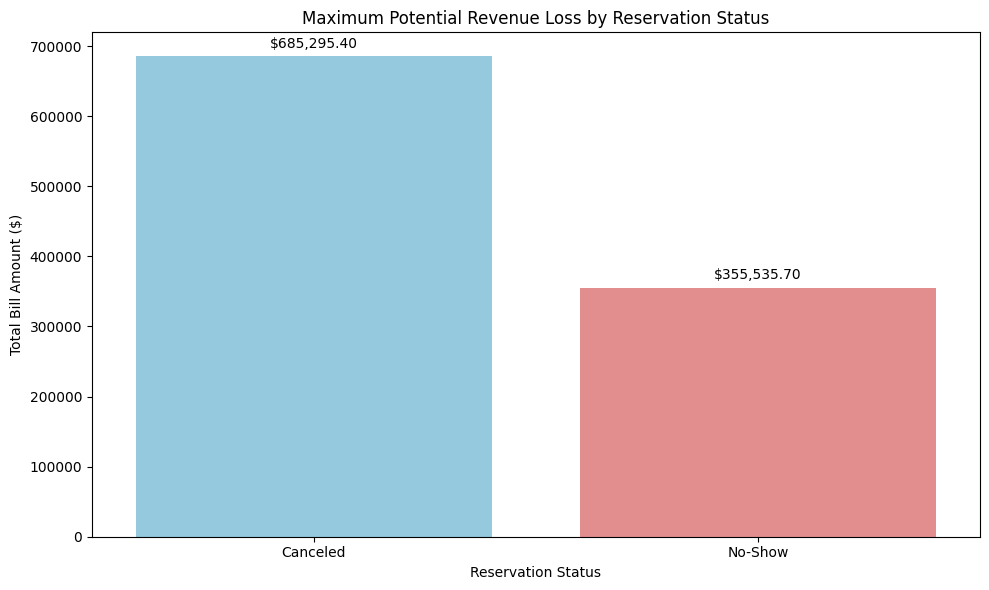

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Reservation_Status and sum 'Total_Bill_amount'
max_potential_loss_by_status = bookings_revenue_loss.groupby('Reservation_Status')['Total_Bill_amount'].sum().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Reservation_Status', y='Total_Bill_amount', data=max_potential_loss_by_status, palette=['skyblue', 'lightcoral'])

# Add labels and title
plt.title('Maximum Potential Revenue Loss by Reservation Status')
plt.xlabel('Reservation Status')
plt.ylabel('Total Bill Amount ($)')

# Add monetary values on top of the bars
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

In [11]:
# Significance
print(round(max_potential_revenue_loss/(max_potential_revenue_loss+revenue_earned) *100,2),'%')

21.48 %


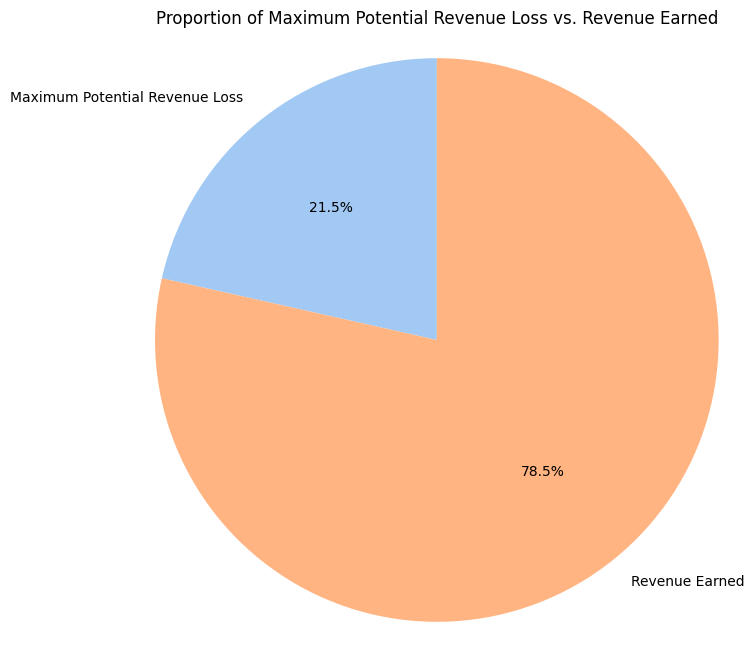

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data for the pie chart
losses = [max_potential_revenue_loss, revenue_earned]
labels = ['Maximum Potential Revenue Loss', 'Revenue Earned']
colors = sns.color_palette('pastel')

plt.figure(figsize=(8, 8))
plt.pie(losses, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Proportion of Maximum Potential Revenue Loss vs. Revenue Earned')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

This assumes that the hotel is not able to re-sell the hotel room within the stay length period. Worst possible outcome

## **Practical Revenue Loss**

In [13]:
practical_revenue_loss = bookings_revenue_loss['Room_Rate']* (1- (bookings_revenue_loss['Discount_Rate']/100))
total_practical_revenue_loss = sum(practical_revenue_loss)
print('$',total_practical_revenue_loss)

$ 573938.5


In [14]:
bookings_revenue_loss['revenue_loss'] = practical_revenue_loss

/tmp/ipykernel_915/575910776.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Reservation_Status', y='revenue_loss', data=practical_loss_by_status, palette=['purple', 'orange'])


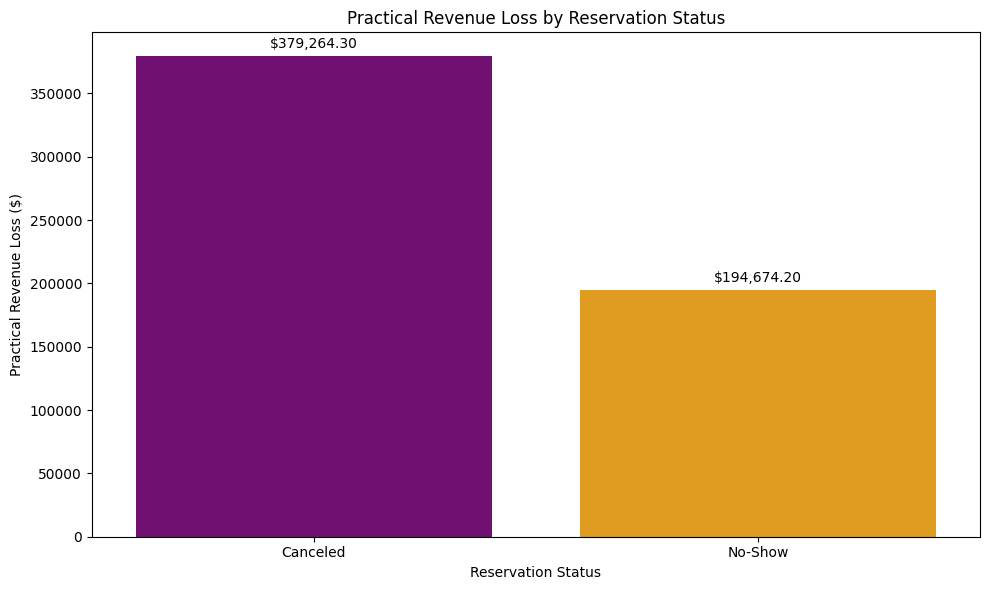

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'revenue_loss' column is correctly calculated and available in bookings_revenue_loss
# This was already done in a previous cell, but re-calculating for clarity/independence if needed.
# bookings_revenue_loss['revenue_loss'] = bookings_revenue_loss['Room_Rate'] * (1 - (bookings_revenue_loss['Discount_Rate'] / 100))

# Group by Reservation_Status and sum 'revenue_loss'
practical_loss_by_status = bookings_revenue_loss.groupby('Reservation_Status')['revenue_loss'].sum().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Reservation_Status', y='revenue_loss', data=practical_loss_by_status, palette=['purple', 'orange'])

# Add labels and title
plt.title('Practical Revenue Loss by Reservation Status')
plt.xlabel('Reservation Status')
plt.ylabel('Practical Revenue Loss ($)')

# Add monetary values on top of the bars
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

Based on our research, we are assuming that the hotel will only lose revenue on the first night not all the nights, so the room rates are summed, taking into account the discount rate as well. While bookings which were cancelled well in advance could potentially mean that the room could be resold prior to the first night, no data regarding cancellation dates have been provided so for the purpose of simplicity we are assuming that first night is lost.

In [16]:
# Significance
print(round(total_practical_revenue_loss/revenue_earned *100,2),'%')

15.09 %


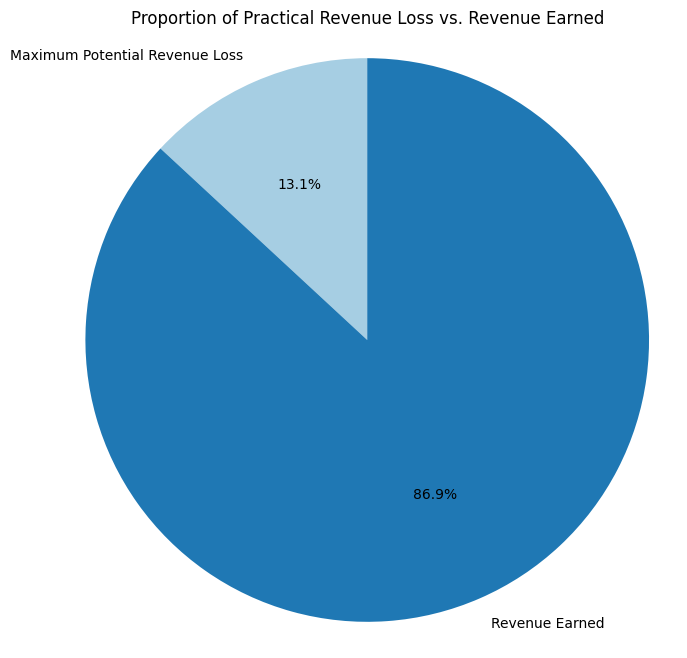

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data for the pie chart
losses = [total_practical_revenue_loss, revenue_earned]
labels = ['Maximum Potential Revenue Loss', 'Revenue Earned']
colors = sns.color_palette('Paired')

plt.figure(figsize=(8, 8))
plt.pie(losses, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Proportion of Practical Revenue Loss vs. Revenue Earned')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Its important to note that revenue losses can be attributed to people cancelling in advance more.

# **Analysis**

### Age

In [18]:
bookings_revenue_loss

,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Adults,Children,Babies,...,Room_Rate,Lead_Time_Days,Stay_Length_Days,Total_Guests,Total_Bill_amount,Booking_month,Booking_dayofweek,Checkin_month,Checkin_dayofweek,revenue_loss
8004,M,44,African American,College,>100K,South,City Hotel,2,2,0,...,115,82,2,4,207.0,2,0,5,5,103.5
8005,F,40,African American,College,>100K,South,City Hotel,2,1,0,...,122,21,2,3,207.4,9,0,9,0,103.7
8011,F,41,caucasian,College,>100K,West,City Hotel,2,2,1,...,112,109,1,4,89.6,10,1,1,5,89.6
8013,M,24,Latino,Grad,25K --50K,East,City Hotel,2,1,1,...,160,194,1,3,128.0,12,5,7,3,128.0
8015,F,28,caucasian,College,50K -- 100K,South,Airport Hotels,1,1,1,...,209,75,1,2,209.0,5,4,7,2,209.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17684,M,44,caucasian,College,<25K,West,City Hotel,2,2,1,...,124,172,1,4,111.6,3,5,8,2,111.6
17686,F,25,Latino,College,50K -- 100K,East,Resort,1,3,1,...,206,106,1,4,195.7,5,1,8,2,195.7
17689,M,63,Latino,Grad,50K -- 100K,East,Airport Hotels,3,1,0,...,232,49,1,4,232.0,7,2,8,2,232.0
17691,F,49,Asian American,College,25K --50K,South,Airport Hotels,2,1,0,...,194,127,1,3,116.4,4,1,8,2,116.4


In [19]:
revenue_loss_per_age = bookings_revenue_loss.groupby('Age')['revenue_loss'].sum().reset_index()
revenue_loss_per_age

,Age,revenue_loss
0,18,7912.35
1,19,10718.60
2,20,13097.05
3,21,12109.95
4,22,10859.10
5,23,9393.25
6,24,9830.65
7,25,10576.55
8,26,11569.10
9,27,11324.90


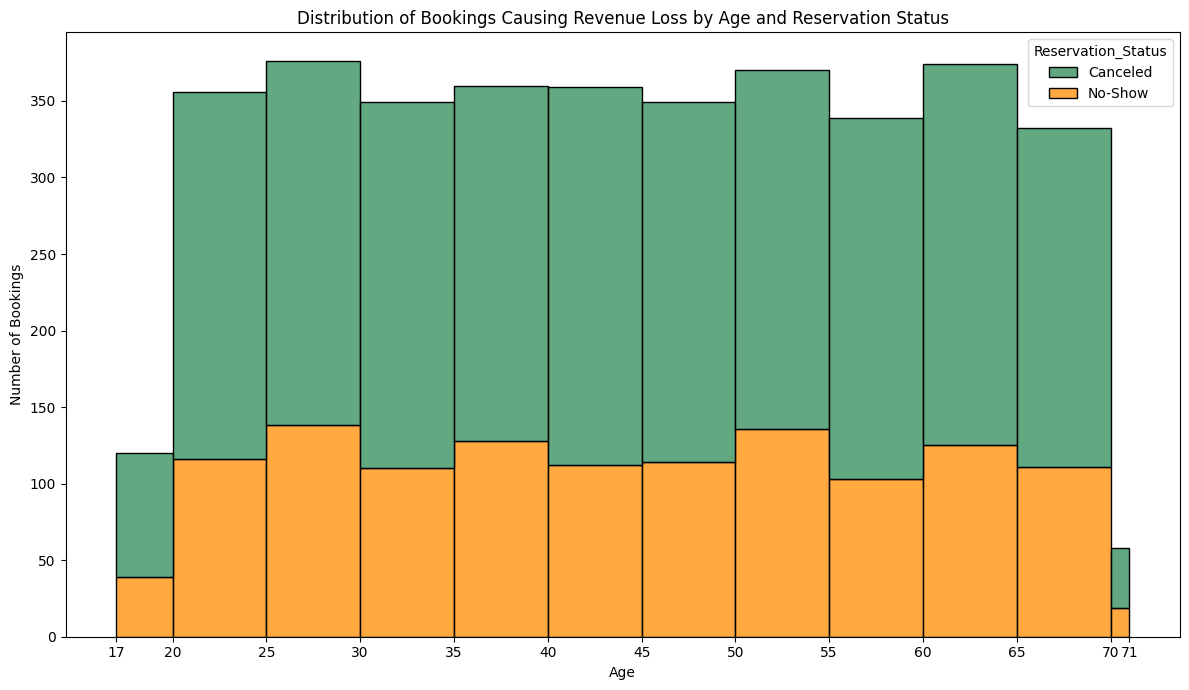

In [20]:
plt.figure(figsize=(12, 7))

# Define bins for age groups, consistent with previous categorization
bins = [17, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 71]

# Plotting the histogram of Age, stacked by Reservation_Status
sns.histplot(data=bookings_revenue_loss, x='Age', hue='Reservation_Status',
             bins=bins, multiple='stack', palette=['seagreen', 'darkorange'], edgecolor='black')

plt.title('Distribution of Bookings Causing Revenue Loss by Age and Reservation Status')
plt.xlabel('Age')
plt.ylabel('Number of Bookings')

# Set x-ticks to the bin edges for clear demarcation of age groups
plt.xticks(bins)

# The legend is automatically handled by sns.histplot when 'hue' is used.
# Removed the redundant plt.legend() call.
plt.tight_layout()
plt.show()

20-65 year old contribute to revenue loss due to their busy nature. They may have work commitments (e.g Meeting rescheueling), delays in flights and family priorities (Takahashi, 2025). Moreover, leisure travelers are very price sensitive and may cancel a booking if they find a more economical alternative, and consider many factors like pool, menu, etc. (Dohee Kim, 2013)

### Region

In [21]:
revenue_loss_per_region = bookings_revenue_loss.groupby('Country_region')['revenue_loss'].sum().reset_index()


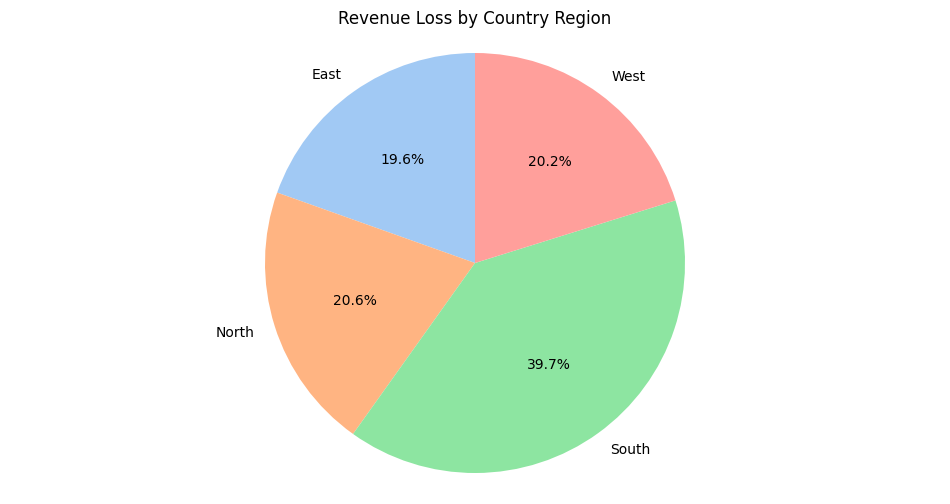

In [22]:
plt.figure(figsize=(12, 6))
plt.pie(revenue_loss_per_region['revenue_loss'], labels=revenue_loss_per_region['Country_region'], colors = sns.color_palette('pastel'),autopct='%1.1f%%',startangle = 90)
plt.title('Revenue Loss by Country Region')
plt.axis('equal') # Ensure pie chart is circular
plt.show()

People from the south contribute to revenue loss more. This is due to the higher prevalance of storms and hurricanes which causes flight delays & and forces customers to cancel trips out of the neccessity of safety. Hurriance Milton casued hotels in Tampa and Orlando to drop in thier Revenue Per Available Room (RevPAR) by 9.8% & 5.3% respectively (Kirk, 2024)

### Hotel Type

In [23]:
revenue_loss_per_hotel = bookings_revenue_loss.groupby('Hotel_Type')['revenue_loss'].sum().reset_index()


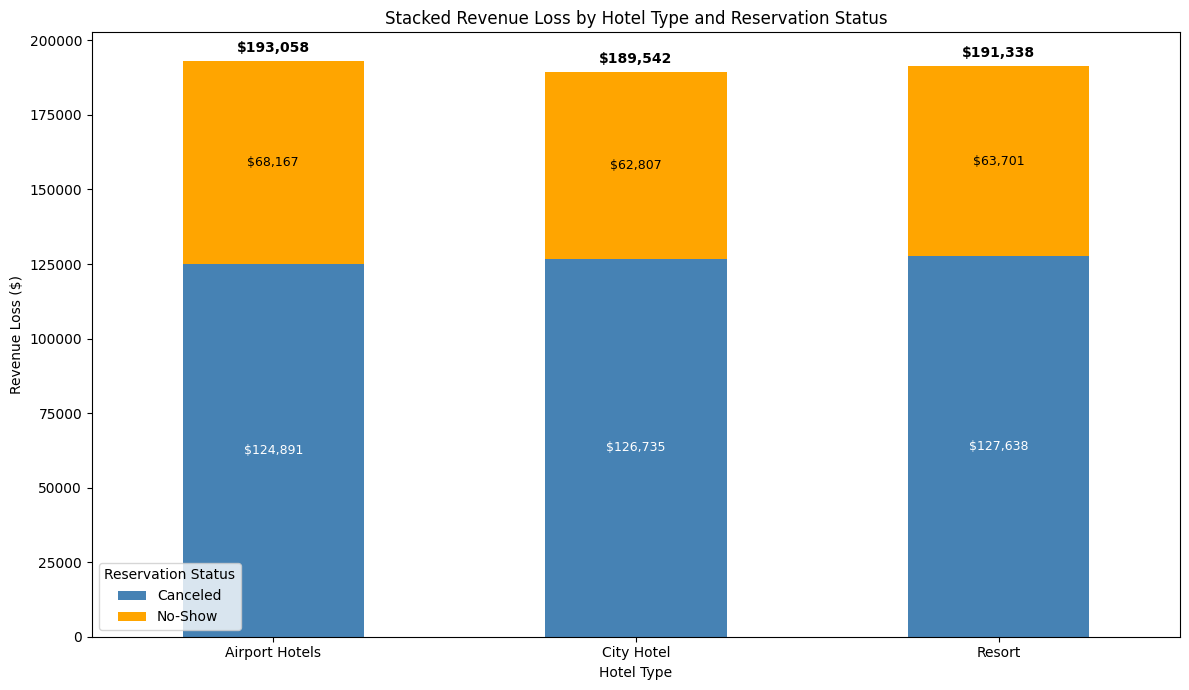

In [24]:
# Group by Hotel_Type and Reservation_Status for stacked bar chart
revenue_loss_stacked_hotel = bookings_revenue_loss.groupby(['Hotel_Type', 'Reservation_Status'])['revenue_loss'].sum().unstack(fill_value=0)

# Plotting the stacked bar chart
ax = revenue_loss_stacked_hotel.plot(kind='bar', stacked=True, figsize=(12, 7), color=['steelblue', 'orange'])
plt.title('Stacked Revenue Loss by Hotel Type and Reservation Status')
plt.xlabel('Hotel Type')
plt.ylabel('Revenue Loss ($)')
plt.xticks(rotation=0)
plt.legend(title='Reservation Status')

# Add total values on top of each stacked bar and individual component values
for i, hotel_type in enumerate(revenue_loss_stacked_hotel.index):
    total_loss = revenue_loss_stacked_hotel.loc[hotel_type].sum()
    canceled_loss = revenue_loss_stacked_hotel.loc[hotel_type, 'Canceled']
    no_show_loss = revenue_loss_stacked_hotel.loc[hotel_type, 'No-Show']

    # Total value
    plt.text(i, total_loss + 2000, f'${total_loss:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Canceled value
    plt.text(i, canceled_loss / 2, f'${canceled_loss:,.0f}', ha='center', va='center', fontsize=9, color='white')

    # No-Show value
    plt.text(i, canceled_loss + no_show_loss / 2, f'${no_show_loss:,.0f}', ha='center', va='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()

Revenue Loss across hotel types appear to be very even. However it must be noted that the reasoning is different. Airport & City Hotels mainly cater to businessman which may cancel due to meeting rescheduling & proximity(Kirk, 2024). However, resorts which cater to tourists and families cancel due to price hunting, facilties (e.g Beachs & Pools) (Dohee Kim, 2013)

### Income Level

/tmp/ipykernel_915/2710482369.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_loss_stacked_income = bookings_revenue_loss.groupby(['Income', 'Reservation_Status'])['revenue_loss'].sum().unstack(fill_value=0)


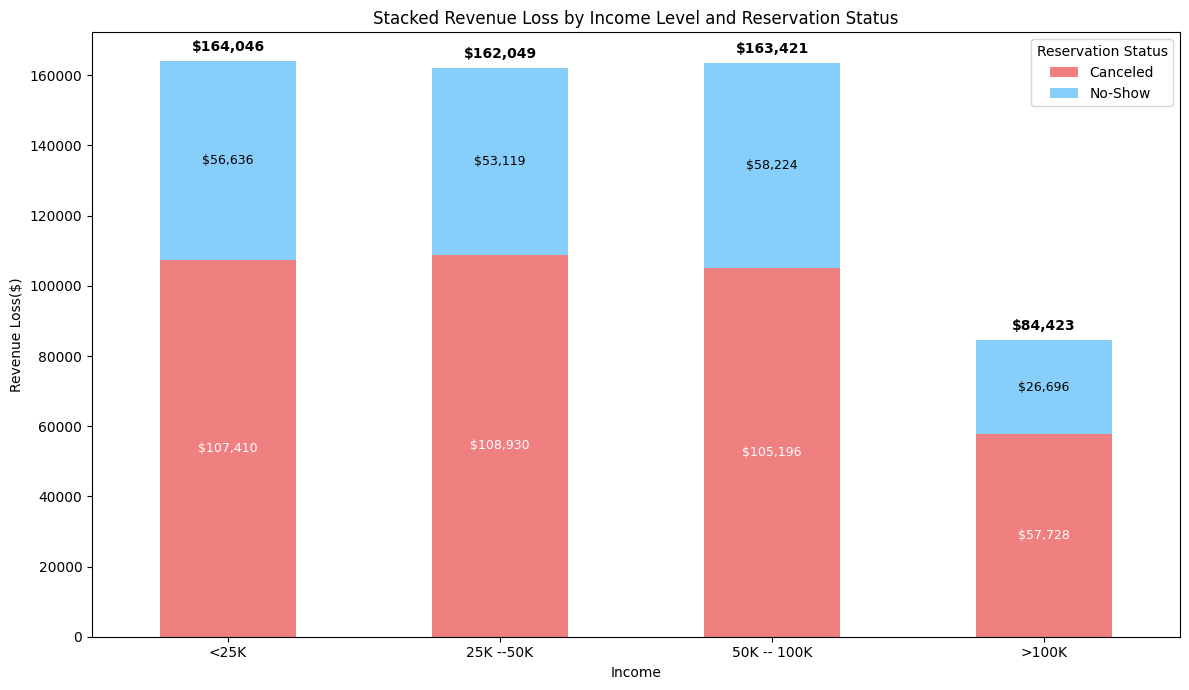

In [25]:
revenue_loss_per_income = bookings_revenue_loss.groupby('Income')['revenue_loss'].sum().reset_index()

# Define the desired order for income levels
income_order = ['<25K', '25K --50K', '50K -- 100K', '>100K']

# Convert 'Income' column to a categorical type with the specified order
bookings_revenue_loss['Income'] = pd.Categorical(bookings_revenue_loss['Income'], categories=income_order, ordered=True)

# Group by Income and Reservation_Status for stacked bar chart
revenue_loss_stacked_income = bookings_revenue_loss.groupby(['Income', 'Reservation_Status'])['revenue_loss'].sum().unstack(fill_value=0)

# Sort the DataFrame by the ordered 'Income' column
revenue_loss_stacked_income = revenue_loss_stacked_income.loc[income_order]

# Plotting the stacked bar chart
ax = revenue_loss_stacked_income.plot(kind='bar', stacked=True, figsize=(12, 7), color=['lightcoral', 'lightskyblue'])
plt.xlabel('Income')
plt.ylabel('Revenue Loss($)')
plt.title('Stacked Revenue Loss by Income Level and Reservation Status')
plt.xticks(rotation=0)
plt.legend(title='Reservation Status')

# Add total values on top of each stacked bar and individual component values
for i, income_level in enumerate(revenue_loss_stacked_income.index):
    total_loss = revenue_loss_stacked_income.loc[income_level].sum()
    canceled_loss = revenue_loss_stacked_income.loc[income_level, 'Canceled']
    no_show_loss = revenue_loss_stacked_income.loc[income_level, 'No-Show']

    # Total value
    plt.text(i, total_loss + 2000, f'${total_loss:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Canceled value
    plt.text(i, canceled_loss / 2, f'${canceled_loss:,.0f}', ha='center', va='center', fontsize=9, color='white')

    # No-Show value
    plt.text(i, canceled_loss + no_show_loss / 2, f'${no_show_loss:,.0f}', ha='center', va='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()

People below $100k of income tend to lead to general level of revenue loss. They may cancel due to tight budgets.

#### Revenue Loss by Income Level and Room Rate

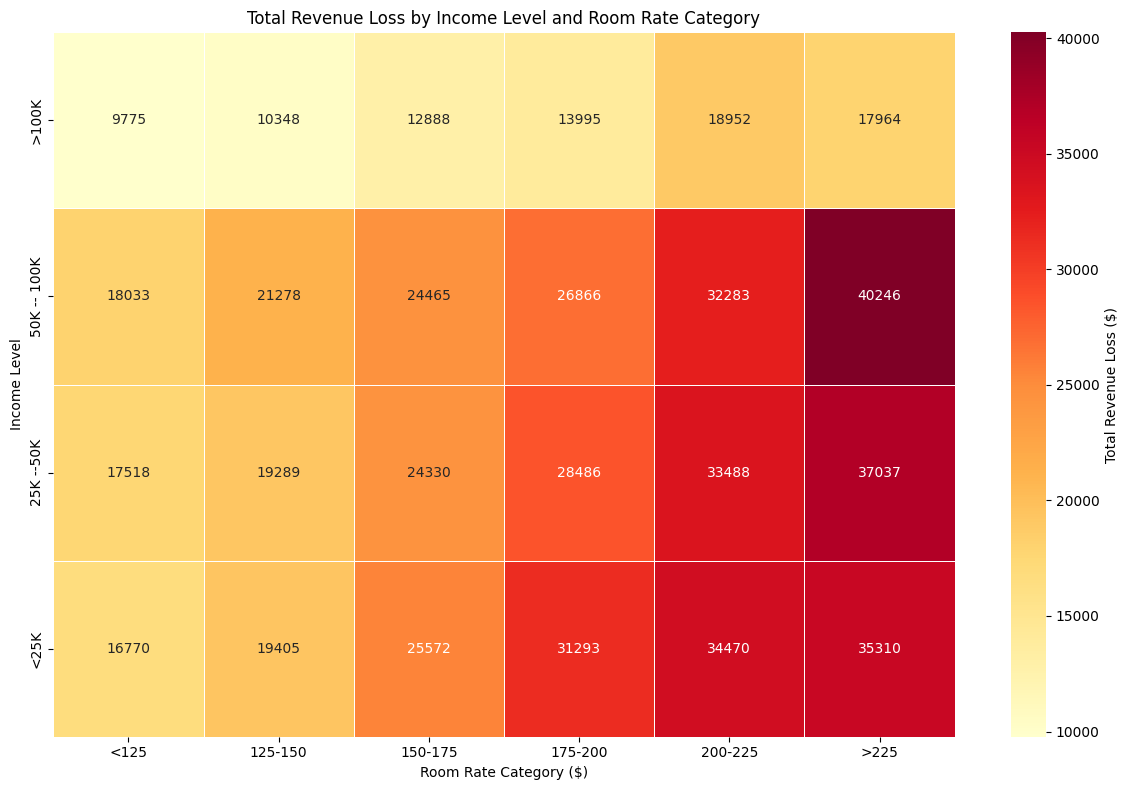

In [26]:
# Re-initialize necessary dataframes and columns, similar to previous cells
hotel = pd.read_csv('/content/drive/MyDrive/IIT/Year 2/DSPL /Coursework/Hotel Chain A - Supporting Resources/Cleaned_original.csv')
bookings_revenue_loss = hotel[((hotel['Reservation_Status'] == 'Canceled') | (hotel['Reservation_Status'] == 'No-Show')) & ((hotel['Deposit_type'] == 'Refundable') | (hotel['Deposit_type'] == 'No Deposit'))].copy()
practical_revenue_loss = bookings_revenue_loss['Room_Rate']* (1- (bookings_revenue_loss['Discount_Rate']/100))
bookings_revenue_loss['revenue_loss'] = practical_revenue_loss

# Define bins and labels for Room_Rate_Category
bins = [100, 125, 150, 175, 200, 225, 250]
labels = [f'<{bins[1]}', f'{bins[1]}-{bins[2]}', f'{bins[2]}-{bins[3]}', f'{bins[3]}-{bins[4]}', f'{bins[4]}-{bins[5]}', f'>{bins[5]}']
bookings_revenue_loss.loc[:, 'Room_Rate_Category'] = pd.cut(bookings_revenue_loss['Room_Rate'], bins=bins, labels=labels, right=False)

# Define the desired order for income levels
income_order = ['>100K','50K -- 100K','25K --50K','<25K']
bookings_revenue_loss['Income'] = pd.Categorical(bookings_revenue_loss['Income'], categories=income_order, ordered=True)

# Group by Income and Room_Rate_Category and sum the revenue_loss
# Explicitly setting observed=False to suppress FutureWarning
heatmap_data = bookings_revenue_loss.groupby(['Income', 'Room_Rate_Category'], observed=False)['revenue_loss'].sum().unstack(fill_value=0)

# Ensure the order of columns (Room_Rate_Category) in the heatmap
heatmap_data = heatmap_data[labels]

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=.5, cbar_kws={'label': 'Total Revenue Loss ($)'})
plt.title('Total Revenue Loss by Income Level and Room Rate Category')
plt.xlabel('Room Rate Category ($)')
plt.ylabel('Income Level')
plt.tight_layout()
plt.show()

As room rate increases revenue loss increases with the exception of the upper income bracket

### Total Revenue Loss by Deposit Type & Room Rate

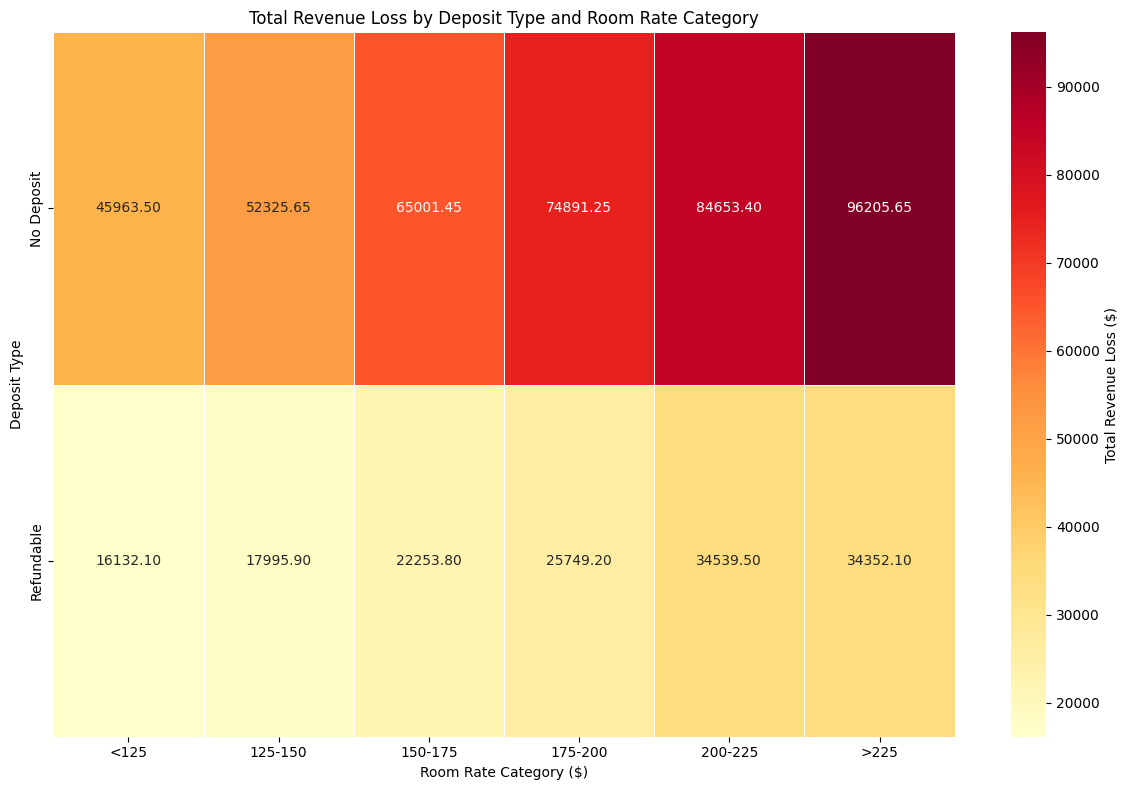

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the figure size
plt.figure(figsize=(12, 8))

# 2 & 5. Create the heatmap with annotations, specific format, and color bar label
sns.heatmap(deposit_room_rate_loss, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=.5, cbar_kws={'label': 'Total Revenue Loss ($)'})

# 3. Add a clear title
plt.title('Total Revenue Loss by Deposit Type and Room Rate Category')

# 4. Label the x-axis and y-axis
plt.xlabel('Room Rate Category ($)')
plt.ylabel('Deposit Type')

# 6. Final display adjustments
plt.tight_layout()
plt.show()

### Revenue Loss from Cancellations by Room Rate and Income Level

In [54]:
canceled_bookings = bookings_revenue_loss[bookings_revenue_loss['Reservation_Status'] == 'Canceled'].copy()
rr_bins = [100, 125, 150, 175, 200, 225, 250]
rr_labels = ['<125', '125-150', '150-175', '175-200', '200-225', '>225']
canceled_bookings.loc[:, 'Room_Rate_Category'] = pd.cut(canceled_bookings['Room_Rate'], bins=rr_bins, labels=rr_labels, right=False)

income_order = ['<25K', '25K --50K', '50K -- 100K', '>100K']
canceled_bookings.loc[:, 'Income'] = pd.Categorical(canceled_bookings['Income'], categories=income_order, ordered=True)

canceled_heatmap_data = canceled_bookings.groupby(['Income', 'Room_Rate_Category'], observed=False)['revenue_loss'].sum().unstack(fill_value=0)
canceled_heatmap_data = canceled_heatmap_data[rr_labels]

canceled_heatmap_data.head()

Room_Rate_Category,<125,125-150,150-175,175-200,200-225,>225
Income,,,,,,
25K --50K,12235.9,14415.25,17348.70,19691.50,20454.90,23284.10
50K -- 100K,11373.3,14671.25,16994.35,18075.45,19383.55,24448.35
<25K,11290.9,13593.85,16156.60,19673.85,23061.15,22633.85
>100K,6600.4,7472.90,9178.15,8199.55,13034.55,12991.95


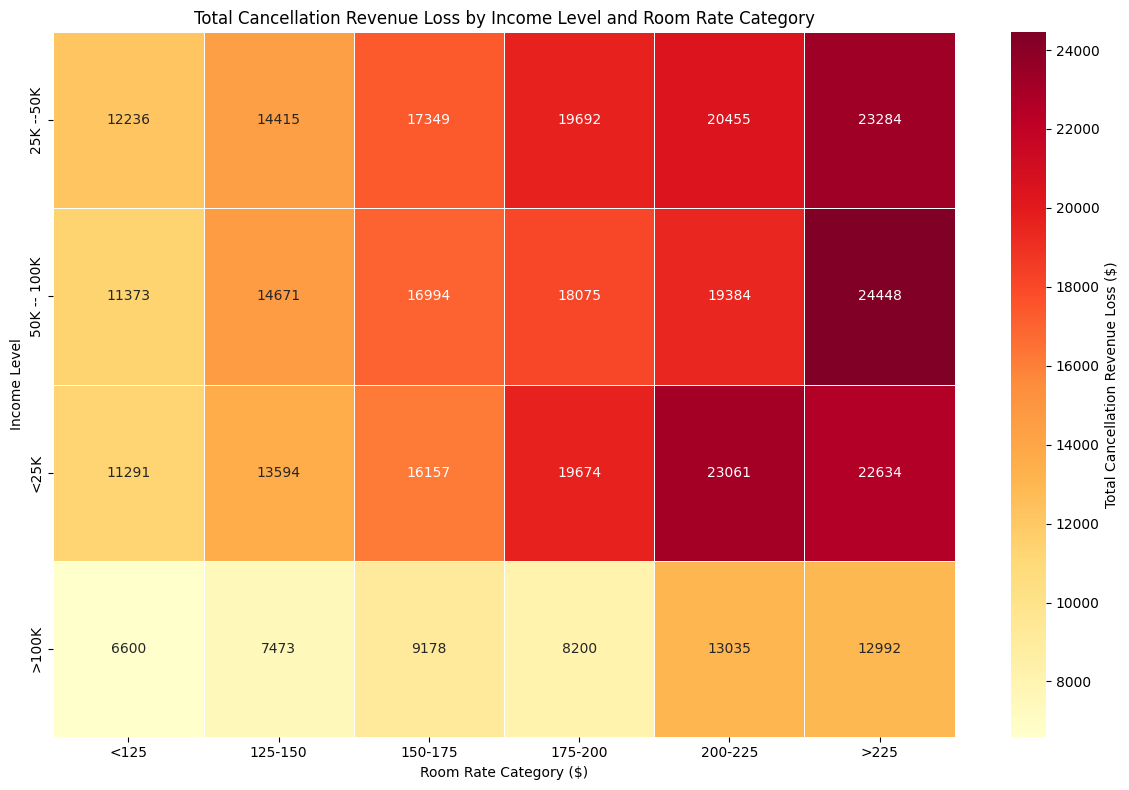

In [55]:
plt.figure(figsize=(12, 8))
sns.heatmap(canceled_heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=.5, cbar_kws={'label': 'Total Cancellation Revenue Loss ($)'})
plt.title('Cancellation Revenue Loss by Income Level and Room Rate Category')
plt.xlabel('Room Rate Category ($)')
plt.ylabel('Income Level')
plt.tight_layout()
plt.show()


### Revenue Loss from Cancellations by Room Rate and Lead Time

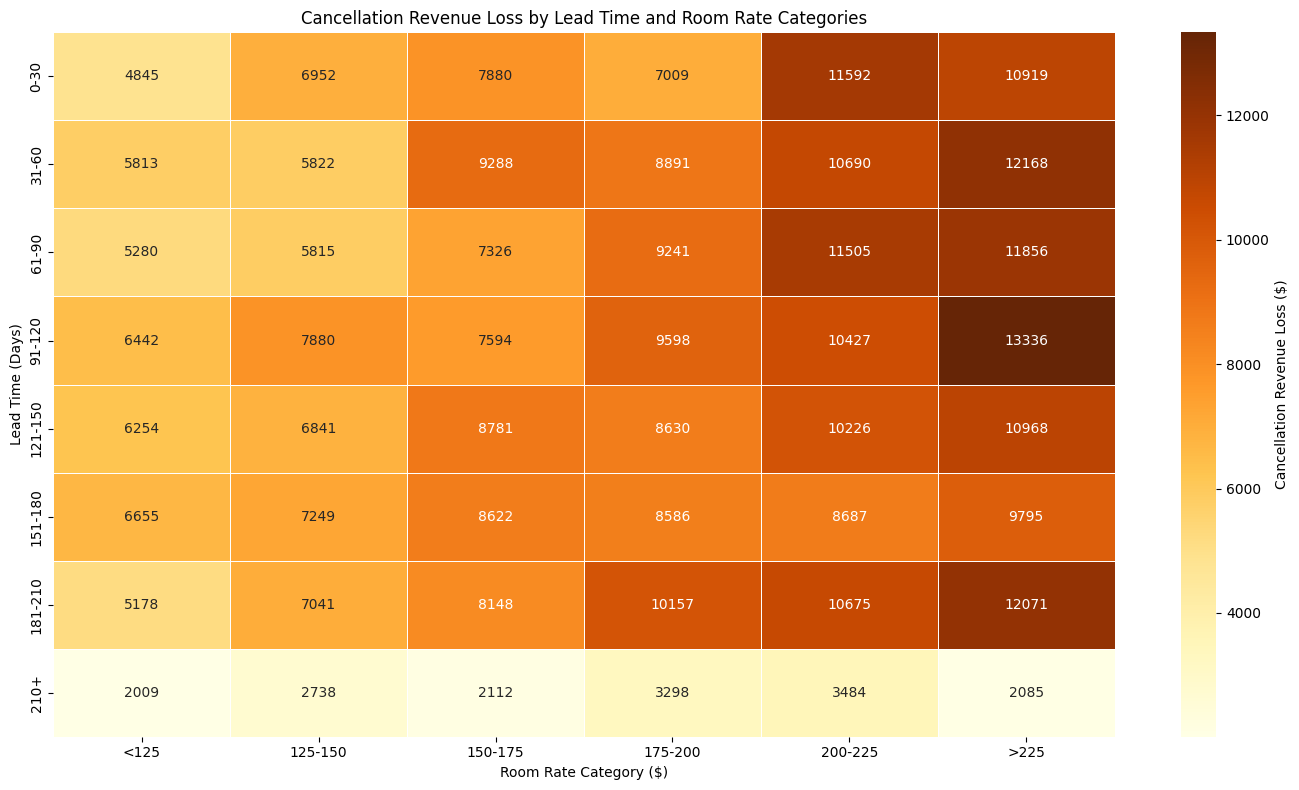

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure data is ready
canceled_only = bookings_revenue_loss[bookings_revenue_loss['Reservation_Status'] == 'Canceled'].copy()

# Define bins and labels for Lead Time
lt_bins = [0, 30, 60, 90, 120, 150, 180, 210, 250]
lt_labels = ['0-30', '31-60', '61-90', '91-120', '121-150', '151-180', '181-210', '210+']
canceled_only['Lead_Time_Category'] = pd.cut(canceled_only['Lead_Time_Days'], bins=lt_bins, labels=lt_labels)

# Define bins and labels for Room Rate
rr_bins = [100, 125, 150, 175, 200, 225, 250]
rr_labels = ['<125', '125-150', '150-175', '175-200', '200-225', '>225']
canceled_only['Room_Rate_Category'] = pd.cut(canceled_only['Room_Rate'], bins=rr_bins, labels=rr_labels)

# Pivot for heatmap
lt_rr_heatmap_data = canceled_only.groupby(['Lead_Time_Category', 'Room_Rate_Category'], observed=False)['revenue_loss'].sum().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(lt_rr_heatmap_data, annot=True, fmt=".0f", cmap="YlOrBr", linewidths=.5, cbar_kws={'label': 'Cancellation Revenue Loss ($)'})
plt.title('Cancellation Revenue Loss by Lead Time and Room Rate Categories')
plt.xlabel('Room Rate Category ($)')
plt.ylabel('Lead Time (Days)')
plt.tight_layout()
plt.show()

In [27]:
rr_bins = [100, 125, 150, 175, 200, 225, 250]
rr_labels = ['<125', '125-150', '150-175', '175-200', '200-225', '>225']

# Create Room_Rate_Category column
bookings_revenue_loss.loc[:, 'Room_Rate_Category'] = pd.cut(bookings_revenue_loss['Room_Rate'], bins=rr_bins, labels=rr_labels, right=False)

# Group and unstack to create heatmap-ready data
deposit_room_rate_loss = bookings_revenue_loss.groupby(['Deposit_type', 'Room_Rate_Category'], observed=False)['revenue_loss'].sum().unstack(fill_value=0)

# Display the head of the resulting dataframe
deposit_room_rate_loss

##Cancellation Revenue Loss by Previous Cancellation and Visit Status


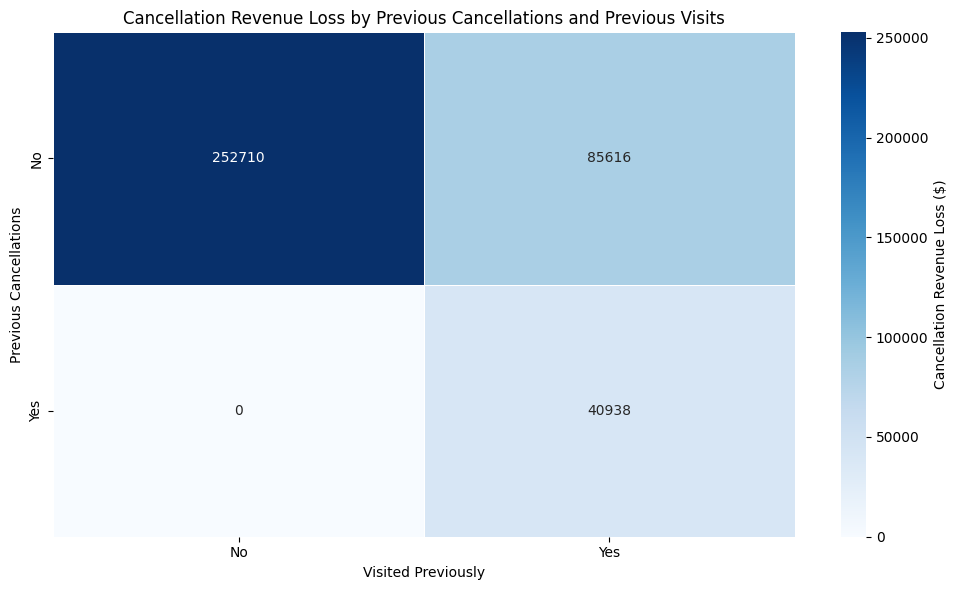

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Re-initialize bookings_revenue_loss to ensure it's defined
hotel = pd.read_csv('/content/drive/MyDrive/IIT/Year 2/DSPL /Coursework/Hotel Chain A - Supporting Resources/Cleaned_original.csv')
bookings_revenue_loss = hotel[((hotel['Reservation_Status'] == 'Canceled') |
 (hotel['Reservation_Status'] == 'No-Show')) & ((hotel['Deposit_type'] == 'Refundable') | (hotel['Deposit_type'] == 'No Deposit'))].copy()
practical_revenue_loss = bookings_revenue_loss['Room_Rate']* (1- (bookings_revenue_loss['Discount_Rate']/100))
bookings_revenue_loss['revenue_loss'] = practical_revenue_loss

# Filter for Canceled bookings
canceled_only = bookings_revenue_loss[bookings_revenue_loss['Reservation_Status'] == 'Canceled'].copy()

# Group by Previous_Cancellations and Visted_Previously and sum the revenue_loss
heatmap_data_cancel_visit = canceled_only.groupby(['Previous_Cancellations', 'Visted_Previously'])['revenue_loss'].sum().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data_cancel_visit, annot=True, fmt=".0f", cmap="Blues", linewidths=.5, cbar_kws={'label': 'Cancellation Revenue Loss ($)'})
plt.title('Cancellation Revenue Loss by Previous Cancellations and Previous Visits')
plt.xlabel('Visited Previously')
plt.ylabel('Previous Cancellations')
plt.tight_layout()
plt.show()

### Key Insights from Heatmap: Cancellation Revenue Loss by Previous Cancellations and Previous Visits

- The heatmap clearly shows that the highest cancellation revenue loss comes from customers who **have NOT previously cancelled** and **have NOT visited previously** (New customers). This segment accounts for the largest loss.
- The second highest loss is from customers who **have NOT previously cancelled** but **HAVE visited previously**. This indicates that even loyal customers who haven't cancelled before can contribute significantly to cancellation losses.
- Customers who **HAVE previously cancelled** contribute much less to the cancellation revenue loss, regardless of whether they have visited previously or not. This could imply that they are either less likely to book or are more careful with their bookings/deposit types.
- The hotel should focus its efforts on reducing cancellation losses from **new customers (no previous cancellations, no previous visits)** and **returning customers who haven't cancelled before (no previous cancellations, have visited previously)**. These two groups represent the largest opportunities for improvement.

In [29]:
bookings_revenue_loss['Room_Rate'].value_counts().sort_index()

,count
Room_Rate,
100,20
101,30
102,25
103,33
104,30
...,...
246,26
247,16
248,19


## Booking Type

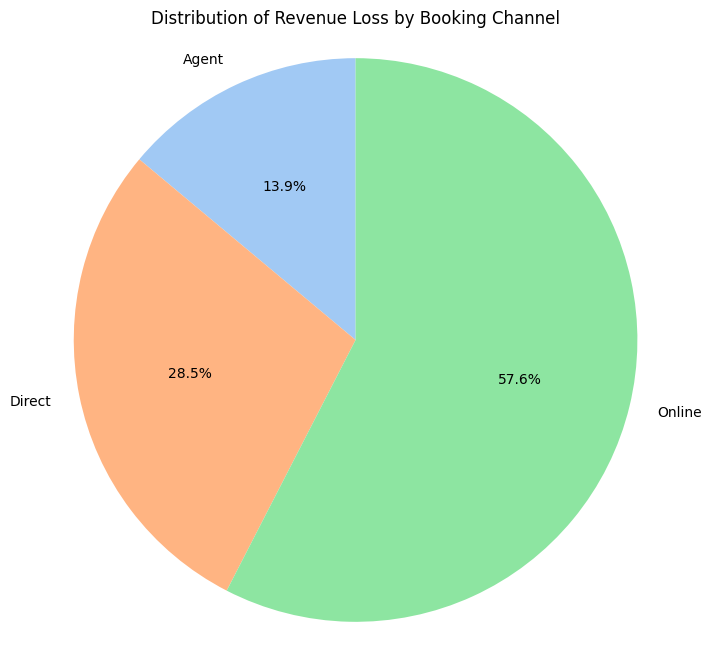

In [31]:
plt.figure(figsize=(8, 8))
booking_channel_loss = bookings_revenue_loss.groupby('Booking_channel')['revenue_loss'].sum().reset_index()
plt.pie(booking_channel_loss['revenue_loss'], labels=booking_channel_loss['Booking_channel'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Revenue Loss by Booking Channel')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [32]:
revenue_loss_by_channel_status = bookings_revenue_loss.groupby(['Booking_channel', 'Reservation_Status'])['revenue_loss'].sum().unstack(fill_value=0)
revenue_loss_by_channel_status

Reservation_Status,Canceled,No-Show
Booking_channel,,
Agent,52093.90,27812.75
Direct,107783.55,55896.75
Online,219386.85,110964.70


Online Travel Agency (OTA) bookings have a significantly higher probability of cancellation (17%) compared to offline bookings (12%) or traditional travel agency bookings (4%) (Martin Falk, 2018).

### Online Revenue Loss by deposit type

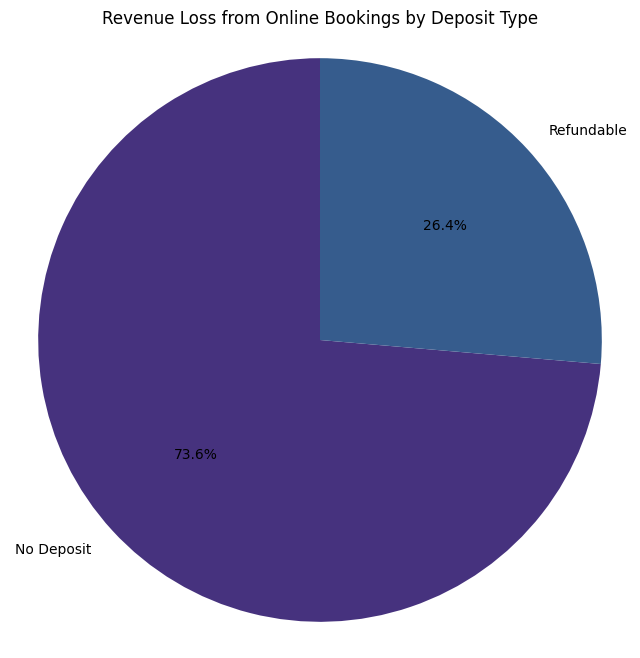

In [33]:
online_bookings_loss = bookings_revenue_loss[bookings_revenue_loss['Booking_channel'] == 'Online']

revenue_loss_by_deposit_online = online_bookings_loss.groupby('Deposit_type')['revenue_loss'].sum().reset_index()

plt.figure(figsize=(8, 8))
plt.pie(revenue_loss_by_deposit_online['revenue_loss'], labels=revenue_loss_by_deposit_online['Deposit_type'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis'))
plt.title('Revenue Loss from Online Bookings by Deposit Type')
plt.axis('equal')
plt.show()

# Lead Time

In [34]:
online_bookings_loss['Lead_Time_Days'].value_counts()

,count
Lead_Time_Days,
124,20
134,20
203,19
198,19
107,18
...,...
43,4
193,4
89,3


In [35]:
print(bookings_revenue_loss['Lead_Time_Days'].describe())

count    3742.000000
mean      110.940406
std        62.961642
min         1.000000
25%        57.000000
50%       110.000000
75%       166.000000
max       222.000000
Name: Lead_Time_Days, dtype: float64


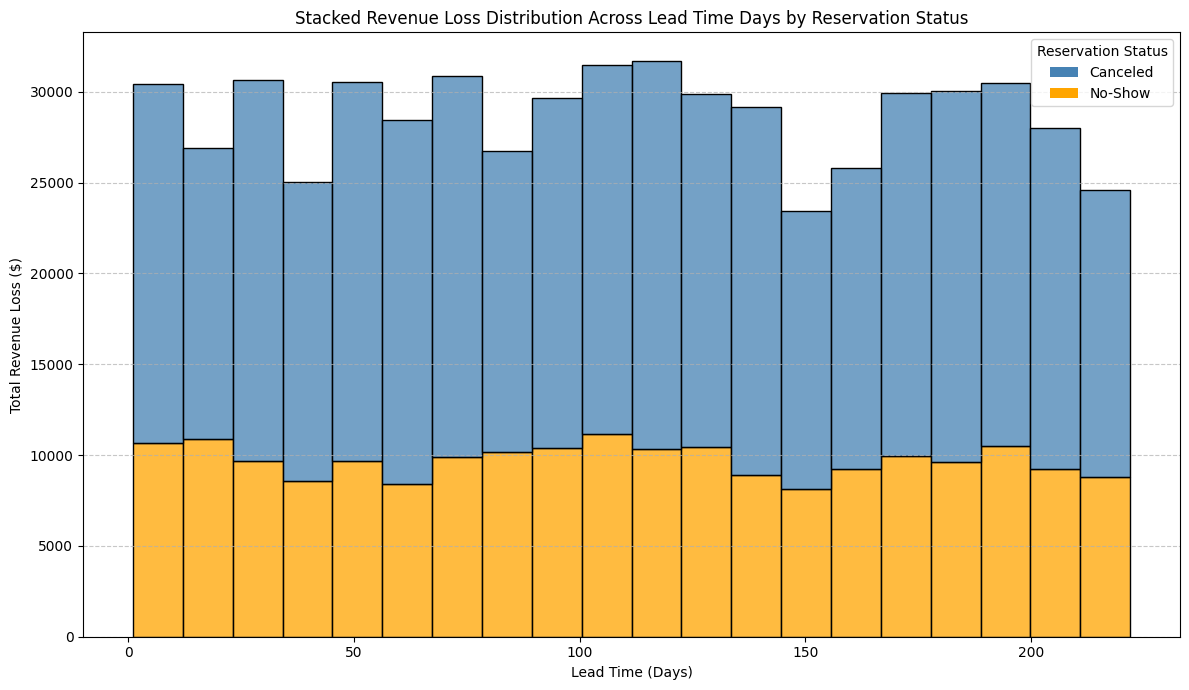

In [36]:
from matplotlib.patches import Patch

plt.figure(figsize=(12, 7))
ax = sns.histplot(data=bookings_revenue_loss, x='Lead_Time_Days', weights='revenue_loss', bins=20, kde=False, hue='Reservation_Status', multiple='stack', palette=['steelblue', 'orange'], edgecolor='black')
plt.title('Stacked Revenue Loss Distribution Across Lead Time Days by Reservation Status')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Total Revenue Loss ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Manually create proxy artists for the legend
legend_elements = [
    Patch(facecolor='steelblue', label='Canceled'),
    Patch(facecolor='orange', label='No-Show')
]
ax.legend(handles=legend_elements, title='Reservation Status')

plt.tight_layout()
plt.show()

In [37]:
rr_bins = [100, 125, 150, 175, 200, 225, 250]
rr_labels = ['<125', '125-150', '150-175', '175-200', '200-225', '>225']

# Create Room_Rate_Category column
bookings_revenue_loss.loc[:, 'Room_Rate_Category'] = pd.cut(bookings_revenue_loss['Room_Rate'], bins=rr_bins, labels=rr_labels, right=False)

# Group and unstack to create heatmap-ready data
deposit_room_rate_loss = bookings_revenue_loss.groupby(['Deposit_type', 'Room_Rate_Category'], observed=False)['revenue_loss'].sum().unstack(fill_value=0)

# Display the head of the resulting dataframe
deposit_room_rate_loss

Room_Rate_Category,<125,125-150,150-175,175-200,200-225,>225
Deposit_type,,,,,,
No Deposit,45963.5,52325.65,65001.45,74891.25,84653.4,96205.65
Refundable,16132.1,17995.90,22253.80,25749.20,34539.5,34352.10


In [38]:
no_show_only = bookings_revenue_loss[bookings_revenue_loss['Reservation_Status'] == 'No-Show'].copy()
no_show_only.head()

,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Adults,Children,Babies,...,Lead_Time_Days,Stay_Length_Days,Total_Guests,Total_Bill_amount,Booking_month,Booking_dayofweek,Checkin_month,Checkin_dayofweek,revenue_loss,Room_Rate_Category
8005,F,40,African American,College,>100K,South,City Hotel,2,1,0,...,21,2,3,207.40,9,0,9,0,103.70,<125
8030,M,28,caucasian,College,<25K,East,City Hotel,2,1,0,...,154,3,3,339.00,12,5,5,5,113.00,<125
8031,F,40,Asian American,High-School,<25K,South,City Hotel,1,3,1,...,213,3,4,210.60,12,1,7,4,70.20,<125
8034,M,46,Latino,High-School,50K -- 100K,South,City Hotel,2,2,0,...,100,1,4,228.95,2,5,5,0,228.95,>225
8036,F,47,caucasian,Mid-School,<25K,South,City Hotel,1,1,0,...,64,1,2,166.25,1,0,3,1,166.25,175-200


In [39]:
lt_bins = [0, 30, 60, 90, 120, 150, 180, 210, 250]
lt_labels = ['0-30', '31-60', '61-90', '91-120', '121-150', '151-180', '181-210', '210+']
no_show_only.loc[:, 'Lead_Time_Category'] = pd.cut(no_show_only['Lead_Time_Days'], bins=lt_bins, labels=lt_labels, right=False)

rr_bins = [100, 125, 150, 175, 200, 225, 250]
rr_labels = ['<125', '125-150', '150-175', '175-200', '200-225', '>225']
no_show_only.loc[:, 'Room_Rate_Category'] = pd.cut(no_show_only['Room_Rate'], bins=rr_bins, labels=rr_labels, right=False)

no_show_only.head()

,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Adults,Children,Babies,...,Stay_Length_Days,Total_Guests,Total_Bill_amount,Booking_month,Booking_dayofweek,Checkin_month,Checkin_dayofweek,revenue_loss,Room_Rate_Category,Lead_Time_Category
8005,F,40,African American,College,>100K,South,City Hotel,2,1,0,...,2,3,207.40,9,0,9,0,103.70,<125,0-30
8030,M,28,caucasian,College,<25K,East,City Hotel,2,1,0,...,3,3,339.00,12,5,5,5,113.00,<125,151-180
8031,F,40,Asian American,High-School,<25K,South,City Hotel,1,3,1,...,3,4,210.60,12,1,7,4,70.20,<125,210+
8034,M,46,Latino,High-School,50K -- 100K,South,City Hotel,2,2,0,...,1,4,228.95,2,5,5,0,228.95,>225,91-120
8036,F,47,caucasian,Mid-School,<25K,South,City Hotel,1,1,0,...,1,2,166.25,1,0,3,1,166.25,175-200,61-90


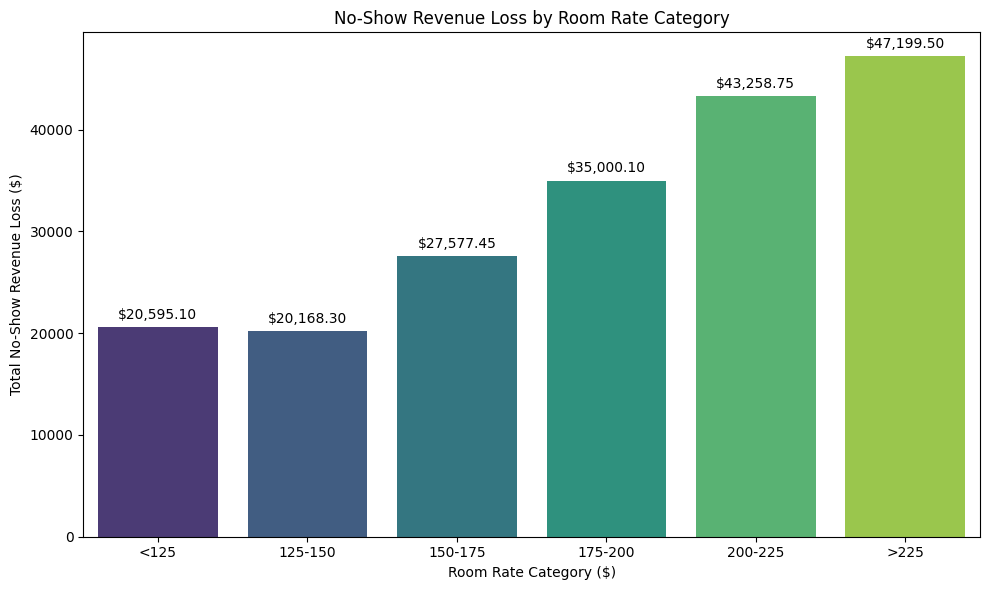

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Re-initialize necessary dataframes and columns
hotel = pd.read_csv('/content/drive/MyDrive/IIT/Year 2/DSPL /Coursework/Hotel Chain A - Supporting Resources/Cleaned_original.csv')
bookings_revenue_loss = hotel[((hotel['Reservation_Status'] == 'Canceled') | (hotel['Reservation_Status'] == 'No-Show')) & ((hotel['Deposit_type'] == 'Refundable') | (hotel['Deposit_type'] == 'No Deposit'))].copy()
practical_revenue_loss = bookings_revenue_loss['Room_Rate']* (1- (bookings_revenue_loss['Discount_Rate']/100))
bookings_revenue_loss['revenue_loss'] = practical_revenue_loss

# Filter for No-Show bookings
no_show_only = bookings_revenue_loss[bookings_revenue_loss['Reservation_Status'] == 'No-Show'].copy()

# Define bins and labels for Room Rate
rr_bins = [100, 125, 150, 175, 200, 225, 250]
rr_labels = ['<125', '125-150', '150-175', '175-200', '200-225', '>225']
no_show_only.loc[:, 'Room_Rate_Category'] = pd.cut(no_show_only['Room_Rate'], bins=rr_bins, labels=rr_labels, right=False)

# Group by Room_Rate_Category and sum 'revenue_loss' for no-shows, explicitly setting observed=False
no_show_loss_by_room_rate = no_show_only.groupby('Room_Rate_Category', observed=False)['revenue_loss'].sum().reset_index()

plt.figure(figsize=(10, 6))
# Assign x variable to hue and set legend=False to address FutureWarning
ax = sns.barplot(x='Room_Rate_Category', y='revenue_loss', data=no_show_loss_by_room_rate, palette='viridis', hue='Room_Rate_Category', legend=False)

# Add labels and title
plt.title('No-Show Revenue Loss by Room Rate Category')
plt.xlabel('Room Rate Category ($)')
plt.ylabel('Total No-Show Revenue Loss ($)')

# Add monetary values on top of the bars
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

The higher the room rate the more likely the customers will not show up

## No-Show Revenue Loss by Previous Cancellations



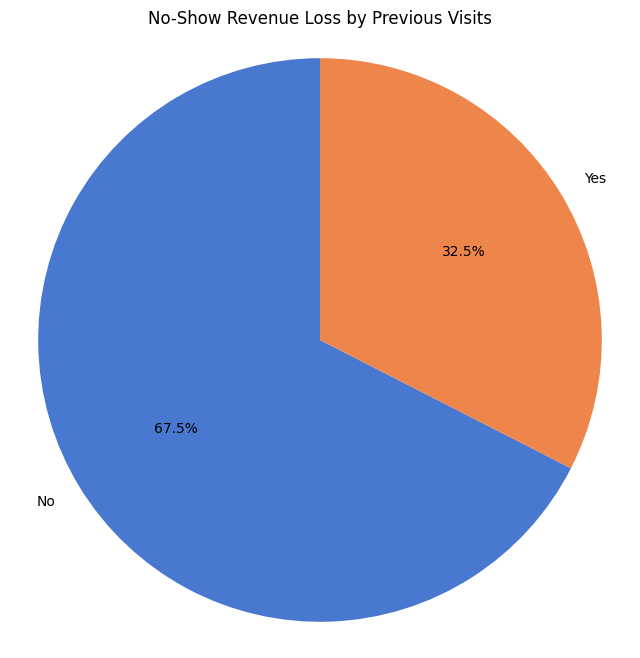

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter for No-Show bookings
no_show_only = bookings_revenue_loss[bookings_revenue_loss['Reservation_Status'] == 'No-Show'].copy()

# Group by Visted_Previously and sum the revenue_loss
no_show_loss_by_prev_visit = no_show_only.groupby('Visted_Previously')['revenue_loss'].sum().reset_index()

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(no_show_loss_by_prev_visit['revenue_loss'],
        labels=no_show_loss_by_prev_visit['Visted_Previously'],
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette('muted'))
plt.title('No-Show Revenue Loss by Previous Visits')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# **Impact of Cancellation Strategies**

## **Implementation of Cancelation Policy by Room Rate**

In [43]:
import pandas as pd

# 1. Filter the hotel DataFrame
canceled_impact_df = hotel[(
    (hotel['Reservation_Status'] == 'Canceled') &
    (hotel['Deposit_type'].isin(['Refundable', 'No Deposit']))
)].copy()

# 2. Function to determine fee percentage
def get_fee_percentage(row):
    rate = row['Room_Rate']
    lead_time = row['Lead_Time_Days']

    if rate < 150:
        fee = 0.05
    elif 150 <= rate < 175:
        fee = 0.10
    elif 175 <= rate < 225:
        fee = 0.15
    else:  # rate >= 225
        fee = 0.20

    if lead_time < 20:
        fee += 0.05
    return fee

# 3. Calculate First_Night_Fee (adjusted for original discount)
canceled_impact_df['Fee_Percentage'] = canceled_impact_df.apply(get_fee_percentage, axis=1)
canceled_impact_df['First_Night_Rate'] = canceled_impact_df['Room_Rate'] * (1 - (canceled_impact_df['Discount_Rate'] / 100))
canceled_impact_df['First_Night_Fee'] = canceled_impact_df['First_Night_Rate'] * canceled_impact_df['Fee_Percentage']

# 4. Calculate Resale_Revenue for remaining nights (90% of original Room_Rate)
def calc_resale(row):
    if row['Stay_Length_Days'] > 1:
        remaining_nights = row['Stay_Length_Days'] - 1
        return remaining_nights * (row['Room_Rate'] * 0.9)
    return 0.0

canceled_impact_df['Resale_Revenue'] = canceled_impact_df.apply(calc_resale, axis=1)

# 5. Calculate Total_Recovered_Revenue
canceled_impact_df['Total_Recovered_Revenue'] = canceled_impact_df['First_Night_Fee'] + canceled_impact_df['Resale_Revenue']

print(f"Total Recovered Revenue: ${canceled_impact_df['Total_Recovered_Revenue'].sum():,.2f}")
canceled_impact_df[['Room_Rate', 'Lead_Time_Days', 'Stay_Length_Days', 'First_Night_Fee', 'Resale_Revenue', 'Total_Recovered_Revenue']].head()

Total Recovered Revenue: $364,881.86


,Room_Rate,Lead_Time_Days,Stay_Length_Days,First_Night_Fee,Resale_Revenue,Total_Recovered_Revenue
8004,115,82,2,5.175,103.5,108.675
8011,112,109,1,4.480,0.0,4.480
8013,160,194,1,12.800,0.0,12.800
8015,209,75,1,31.350,0.0,31.350
8021,162,136,1,16.200,0.0,16.200


## Compare Against Maximum Potential Loss



In [44]:
# 1. Calculate Maximum Potential Revenue Loss
max_potential_loss = bookings_revenue_loss['Total_Bill_amount'].sum()

# 2. Calculate New Strategy Revenue Loss
# Using Total_Recovered_Revenue from canceled_impact_df calculated in the previous step
total_recovered = canceled_impact_df['Total_Recovered_Revenue'].sum()
new_strategy_loss = max_potential_loss - total_recovered

# 3. Create a summary DataFrame for comparison
comparison_strategy_df = pd.DataFrame({
    'Loss_Type': ['Maximum Potential Revenue Loss', 'New Strategy Revenue Loss'],
    'Amount': [max_potential_loss, new_strategy_loss]
})

print(f"Maximum Potential Revenue Loss: ${max_potential_loss:,.2f}")
print(f"New Strategy Revenue Loss: ${new_strategy_loss:,.2f}")
comparison_strategy_df

Maximum Potential Revenue Loss: $1,040,831.10
New Strategy Revenue Loss: $675,949.24


,Loss_Type,Amount
0,Maximum Potential Revenue Loss,1.040831e+06
1,New Strategy Revenue Loss,6.759492e+05


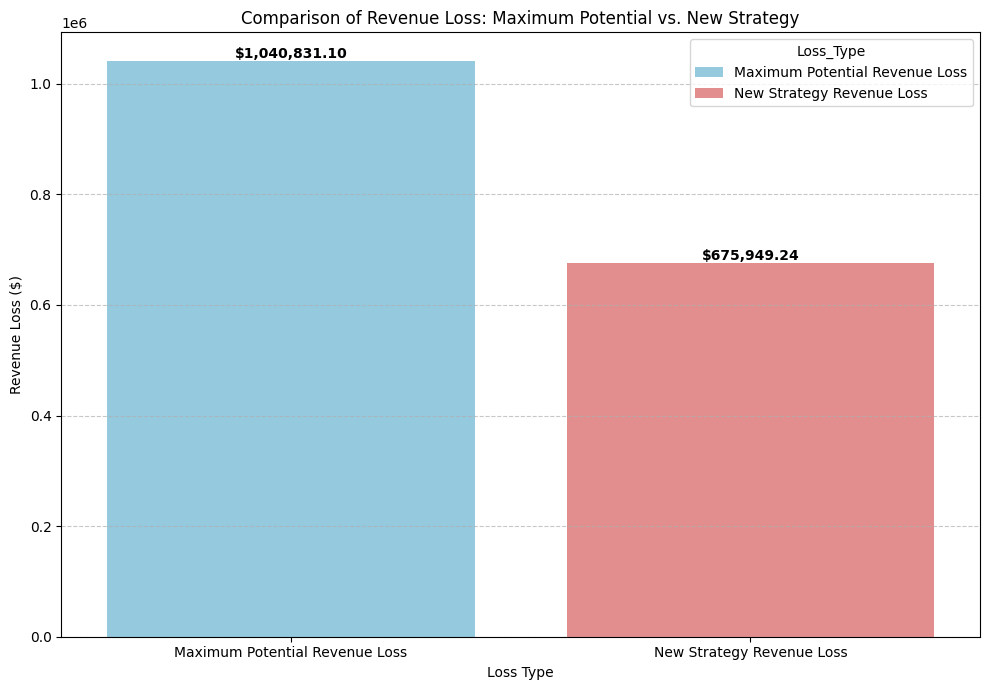

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the figure size
plt.figure(figsize=(10, 7))

# 2 & 3. Create the bar chart with colors and ensure legend
ax = sns.barplot(x='Loss_Type', y='Amount', data=comparison_strategy_df, hue='Loss_Type', palette=['skyblue', 'lightcoral'], legend=True)

# 4. Add title and axis labels
plt.title('Comparison of Revenue Loss: Maximum Potential vs. New Strategy')
plt.xlabel('Loss Type')
plt.ylabel('Revenue Loss ($)')

# 5. Enable a dashed grid on the y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 6. Add text labels on top of each bar
for index, row in comparison_strategy_df.iterrows():
    plt.text(index, row['Amount'], f'${row["Amount"]:,.2f}', color='black', ha='center', va='bottom', fontweight='bold')

# 7. Final display adjustments
plt.tight_layout()
plt.show()

## **Implementation of No Show Policy by Room Rate**

## Calculate No-Show Strategy Impact




In [46]:
import pandas as pd

# 1. Filter the hotel DataFrame for No-Shows with specific deposit types
no_show_impact_df = hotel[
    (hotel['Reservation_Status'] == 'No-Show') &
    (hotel['Deposit_type'].isin(['Refundable', 'No Deposit']))
].copy()

# 2. Define First_Night_Fee logic (full room rate, no discount)
def calculate_no_show_fee(row):
    return row['Room_Rate']

no_show_impact_df['First_Night_Fee'] = no_show_impact_df.apply(calculate_no_show_fee, axis=1)

# 3. Calculate Resale_Revenue for remaining nights (80% of original Room_Rate)
def calculate_no_show_resale(row):
    if row['Stay_Length_Days'] > 1:
        remaining_nights = row['Stay_Length_Days'] - 1
        return remaining_nights * (row['Room_Rate'] * 0.8)
    return 0.0

no_show_impact_df['Resale_Revenue'] = no_show_impact_df.apply(calculate_no_show_resale, axis=1)

# 4. Create Total_Recovered_NoShow_Revenue column
no_show_impact_df['Total_Recovered_NoShow_Revenue'] = no_show_impact_df['First_Night_Fee'] + no_show_impact_df['Resale_Revenue']

# 5. Print the total sum
total_recovered_no_show = no_show_impact_df['Total_Recovered_NoShow_Revenue'].sum()
print(f'Total Recovered No-Show Revenue: ${total_recovered_no_show:,.2f}')
no_show_impact_df[['Room_Rate', 'Stay_Length_Days', 'First_Night_Fee', 'Resale_Revenue', 'Total_Recovered_NoShow_Revenue']].head()

Total Recovered No-Show Revenue: $370,178.40


,Room_Rate,Stay_Length_Days,First_Night_Fee,Resale_Revenue,Total_Recovered_NoShow_Revenue
8005,122,2,122,97.6,219.6
8030,113,3,113,180.8,293.8
8031,117,3,117,187.2,304.2
8034,241,1,241,0.0,241.0
8036,175,1,175,0.0,175.0


## Compare Against Maximum Potential Loss



In [47]:
import pandas as pd

# 1. Calculate Maximum Potential Revenue Loss for No-Shows
max_potential_noshow_loss = no_show_impact_df['Total_Bill_amount'].sum()

# 2. Calculate New Strategy Revenue Loss for No-Shows
# total_recovered_no_show was calculated in the previous cell
new_strategy_noshow_loss = max_potential_noshow_loss - total_recovered_no_show

# 3. Create comparison DataFrame
comparison_noshow_df = pd.DataFrame({
    'Loss_Type': ['Maximum Potential Loss', 'New Strategy Loss'],
    'Amount': [max_potential_noshow_loss, new_strategy_noshow_loss]
})

# 4. Print results formatted as currency
print(f"Maximum Potential Revenue Loss (No-Shows): ${max_potential_noshow_loss:,.2f}")
print(f"New Strategy Revenue Loss (No-Shows): ${new_strategy_noshow_loss:,.2f}")
comparison_noshow_df

Maximum Potential Revenue Loss (No-Shows): $355,535.70
New Strategy Revenue Loss (No-Shows): $-14,642.70


,Loss_Type,Amount
0,Maximum Potential Loss,355535.7
1,New Strategy Loss,-14642.7


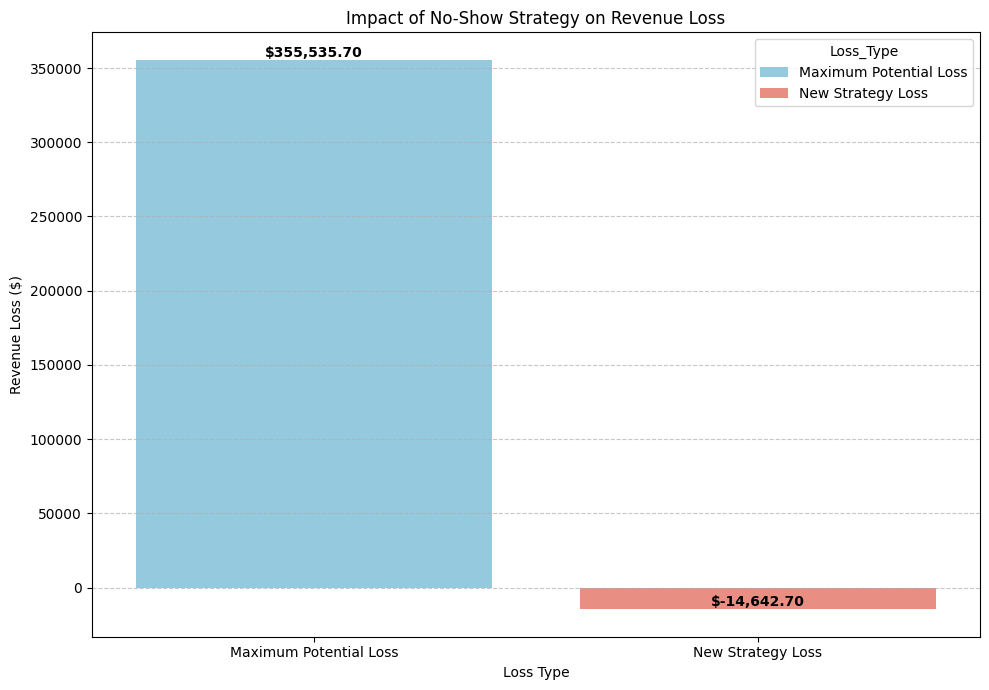

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the figure size
plt.figure(figsize=(10, 7))

# 2 & 3. Create the bar chart with custom colors and ensure legend
ax = sns.barplot(x='Loss_Type', y='Amount', data=comparison_noshow_df, hue='Loss_Type', palette=['skyblue', 'salmon'], legend=True)

# 4. Add title and axis labels
plt.title('Impact of No-Show Strategy on Revenue Loss')
plt.xlabel('Loss Type')
plt.ylabel('Revenue Loss ($)')

# 5. Enable a dashed grid on the y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 6. Add text labels on top of each bar formatted as currency
for index, row in comparison_noshow_df.iterrows():
    plt.text(index, row['Amount'], f'${row["Amount"]:,.2f}', color='black', ha='center', va='bottom', fontweight='bold')

# 7. Adjust layout and show plot
plt.tight_layout()
plt.show()